# Mental Health Disorder Prevalence — Anxiety Prediction
**Mission:** Predict a country's **Anxiety disorder prevalence** (share of population) for a given year, using its other mental-health disorder prevalences plus geographic and temporal context. This helps estimate anxiety burden for country-years where direct anxiety surveillance data is sparse or missing.

**Dataset:** Mental Illnesses Prevalence (Our World in Data / IHME Global Burden of Disease) — [Kaggle](https://www.kaggle.com/datasets/imtkaggleteam/mental-health)
**File used:** `mental_illnesses_prevalence.csv`
**Target Variable:** `Anxiety` (Anxiety disorders, share of population, age-standardized)

---
## Section 1: Setup & Data Loading

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('All libraries loaded successfully.')

All libraries loaded successfully.


In [2]:
# Load dataset
df = pd.read_csv('mental_illnesses_prevalence.csv')

# Original column names are very long; rename to short, clean names
df.columns = ['Entity', 'Code', 'Year', 'Schizophrenia', 'Depressive',
              'Anxiety', 'Bipolar', 'Eating']

print(f'Dataset shape: {df.shape}')
print(f'Countries (Entity): {df["Entity"].nunique()}')
print(f'Year range: {df["Year"].min()} - {df["Year"].max()}')
df.head()

Dataset shape: (6420, 8)
Countries (Entity): 214
Year range: 1990 - 2019


,Entity,Code,Year,Schizophrenia,Depressive,Anxiety,Bipolar,Eating
0,Afghanistan,AFG,1990,0.223206,4.996118,4.713314,0.703023,0.127700
1,Afghanistan,AFG,1991,0.222454,4.989290,4.702100,0.702069,0.123256
2,Afghanistan,AFG,1992,0.221751,4.981346,4.683743,0.700792,0.118844
3,Afghanistan,AFG,1993,0.220987,4.976958,4.673549,0.700087,0.115089
4,Afghanistan,AFG,1994,0.220183,4.977782,4.670810,0.699898,0.111815


---
## Section 2: Exploratory Data Analysis (EDA) & Visualizations

In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().T

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 6420 entries, 0 to 6419
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Entity         6420 non-null   str    
 1   Code           6150 non-null   str    
 2   Year           6420 non-null   int64  
 3   Schizophrenia  6420 non-null   float64
 4   Depressive     6420 non-null   float64
 5   Anxiety        6420 non-null   float64
 6   Bipolar        6420 non-null   float64
 7   Eating         6420 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 401.4 KB

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Year,6420.0,2004.500000,8.656116,1990.000000,1997.000000,2004.500000,2012.000000,2019.000000
Schizophrenia,6420.0,0.266604,0.039383,0.188416,0.242267,0.273477,0.286575,0.462045
Depressive,6420.0,3.767036,0.925286,1.522333,3.080036,3.636772,4.366252,7.645899
Anxiety,6420.0,4.101840,1.050543,1.879996,3.425846,3.939547,4.564164,8.624634
Bipolar,6420.0,0.636968,0.233391,0.181667,0.520872,0.579331,0.844406,1.506730
Eating,6420.0,0.195664,0.138380,0.044780,0.096416,0.144150,0.251167,1.031688


In [4]:
# Missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().sum() / len(df) * 100, 2)
})
print('=== Missing Values ===')
print(missing[missing['Missing Count'] > 0])

=== Missing Values ===
      Missing Count  Missing %
Code            270       4.21


### 2.1 — Distributions of the disorder prevalences (Histograms)

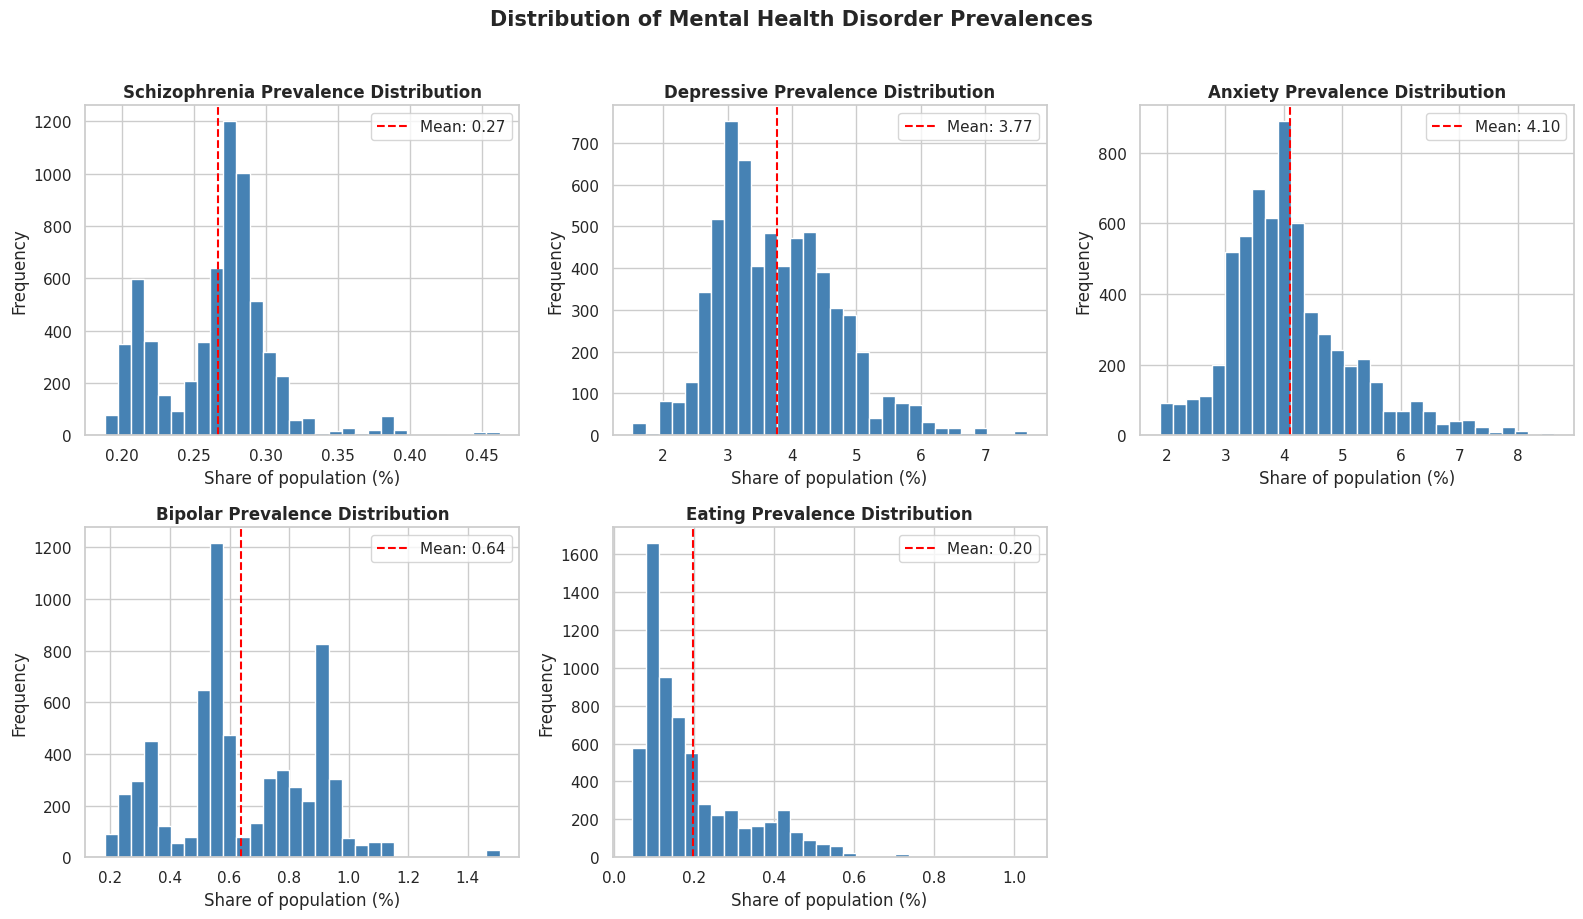

Interpretation: Anxiety prevalence is right-skewed — most countries cluster
at lower values with a tail of high-anxiety countries. It is continuous and
well-suited as a regression target.


In [5]:
disorder_cols = ['Schizophrenia', 'Depressive', 'Anxiety', 'Bipolar', 'Eating']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, disorder_cols):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} Prevalence Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Share of population (%)')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--',
               label=f'Mean: {df[col].mean():.2f}')
    ax.legend()

axes[-1].axis('off')
plt.suptitle('Distribution of Mental Health Disorder Prevalences',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Anxiety prevalence is right-skewed — most countries cluster')
print('at lower values with a tail of high-anxiety countries. It is continuous and')
print('well-suited as a regression target.')

### 2.2 — Correlation Heatmap

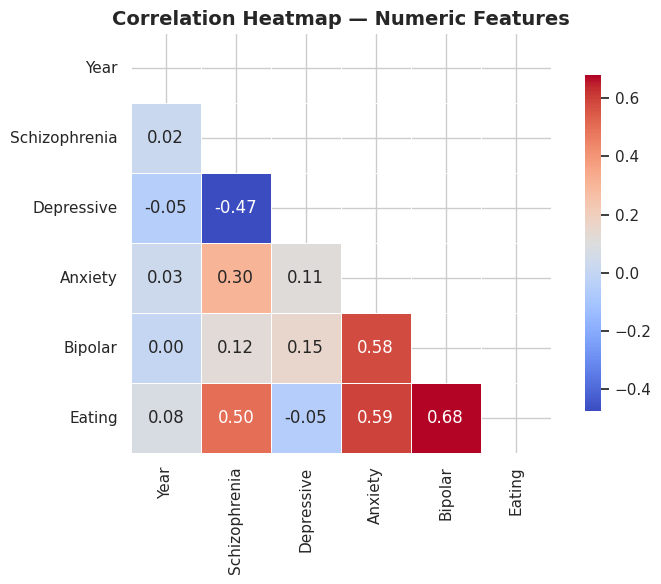

Interpretation:
- Bipolar (0.58) and Eating (0.59) disorders correlate most strongly with Anxiety.
- Depressive disorders show weak positive correlation with Anxiety (0.11).
- Schizophrenia has moderate positive correlation (0.30).
- These guide which features carry the most predictive weight.


In [6]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation:')
print('- Bipolar (0.58) and Eating (0.59) disorders correlate most strongly with Anxiety.')
print('- Depressive disorders show weak positive correlation with Anxiety (0.11).')
print('- Schizophrenia has moderate positive correlation (0.30).')
print('- These guide which features carry the most predictive weight.')

### 2.3 — Scatterplots vs Anxiety (the target)

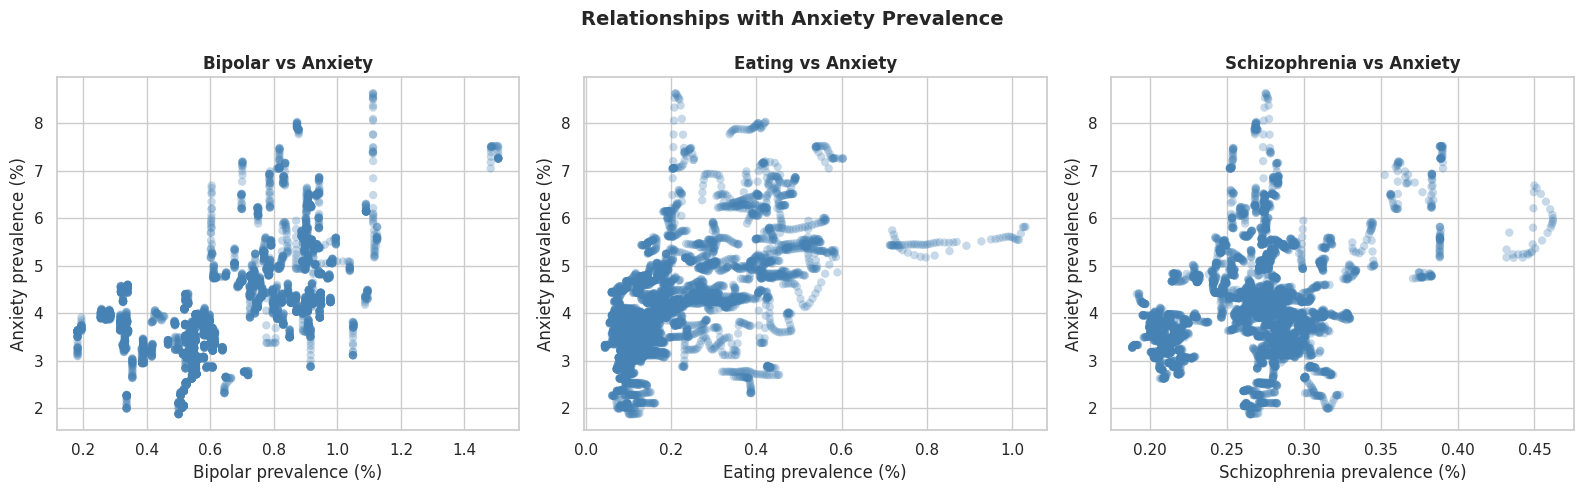

Interpretation: Bipolar and Eating disorder prevalence rise together with
Anxiety, showing usable linear structure for the regression model.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['Bipolar', 'Eating', 'Schizophrenia']):
    ax.scatter(df[col], df['Anxiety'], alpha=0.3, color='steelblue', edgecolors='none')
    ax.set_xlabel(f'{col} prevalence (%)')
    ax.set_ylabel('Anxiety prevalence (%)')
    ax.set_title(f'{col} vs Anxiety', fontweight='bold')

plt.suptitle('Relationships with Anxiety Prevalence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interpretation: Bipolar and Eating disorder prevalence rise together with')
print('Anxiety, showing usable linear structure for the regression model.')

---
## Section 3: Feature Engineering

**Interpretation of feature decisions:**
- **`Code`** — dropped. It is a country ISO code that is a pure duplicate of `Entity` (one-to-one), so it adds no information and has missing values for non-country aggregates.
- **`Entity`** (country name) — the only categorical column. It MUST be converted to numeric via Label Encoding so the model can use it. It carries strong signal because prevalence is heavily country-specific.
- **`Year`** — kept as a numeric feature; captures temporal trend in prevalence.
- **`Schizophrenia`, `Depressive`, `Bipolar`, `Eating`** — kept as numeric predictors.
- **Standardization** — all features are scaled with `StandardScaler` (fit on the training set only) so no single feature dominates due to scale.

### 3.1 — Drop redundant column & handle missing values

In [8]:
# Drop Code — redundant with Entity, and the source of all missing values
print('Missing before drop:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.drop(columns=['Code'])

# No missing values remain in the columns we use
print('\nMissing after dropping Code:')
print(df.isnull().sum().sum(), 'total missing values')

Missing before drop:
Code    270
dtype: int64

Missing after dropping Code:
0 total missing values


### 3.2 — Convert categorical column (Entity) to numeric

In [9]:
# Entity is the categorical column that must be converted to numeric.
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {categorical_cols}')

entity_encoder = LabelEncoder()
df['Entity'] = entity_encoder.fit_transform(df['Entity'].astype(str))

# Save the mapping so the API / app can translate country name <-> code
entity_mapping = dict(zip(entity_encoder.classes_,
                          entity_encoder.transform(entity_encoder.classes_).tolist()))
joblib.dump(entity_encoder, 'entity_encoder.pkl')
print(f'Encoded {len(entity_mapping)} countries to integers 0..{len(entity_mapping)-1}')
print('Example:', dict(list(entity_mapping.items())[:3]))
print('\nDtypes after encoding:')
print(df.dtypes)

Categorical columns to encode: ['Entity']
Encoded 214 countries to integers 0..213
Example: {'Afghanistan': 0, 'Africa (IHME GBD)': 1, 'Albania': 2}

Dtypes after encoding:
Entity             int64
Year               int64
Schizophrenia    float64
Depressive       float64
Anxiety          float64
Bipolar          float64
Eating           float64
dtype: object


### 3.3 — Standardize data & train/test split

In [10]:
# Features and target
X = df.drop(columns=['Anxiety'])
y = df['Anxiety']

FEATURE_COLUMNS = list(X.columns)
print('Feature columns:', FEATURE_COLUMNS)
print('Target: Anxiety')

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set: {X_train_scaled.shape}')
print(f'Test set:     {X_test_scaled.shape}')
print('Standardization complete (mean approx 0, std approx 1 on training data).')

Feature columns: ['Entity', 'Year', 'Schizophrenia', 'Depressive', 'Bipolar', 'Eating']
Target: Anxiety
Training set: (5136, 6)
Test set:     (1284, 6)
Standardization complete (mean approx 0, std approx 1 on training data).


---
## Section 4: Model Training

### 4.1 — Linear Regression with Gradient Descent (SGDRegressor) + Loss Curve

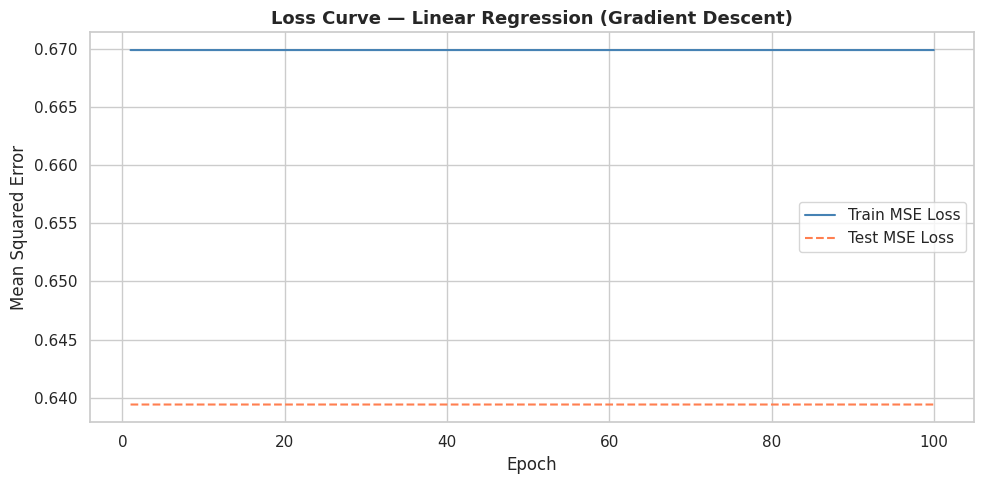

Linear Regression (SGD) — Test RMSE: 0.7996 | R2: 0.4264


In [11]:
# Train SGDRegressor epoch by epoch to capture the loss curve
n_epochs = 100
train_losses, test_losses = [], []

sgd_model = SGDRegressor(max_iter=1, warm_start=True, random_state=42,
                         eta0=0.01, learning_rate='constant')

for epoch in range(n_epochs):
    sgd_model.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_model.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,  sgd_model.predict(X_test_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train MSE Loss', color='steelblue')
plt.plot(range(1, n_epochs + 1), test_losses,  label='Test MSE Loss',
         color='coral', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Mean Squared Error')
plt.title('Loss Curve — Linear Regression (Gradient Descent)',
          fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

sgd_rmse = np.sqrt(test_losses[-1])
sgd_r2   = r2_score(y_test, sgd_model.predict(X_test_scaled))
print(f'Linear Regression (SGD) — Test RMSE: {sgd_rmse:.4f} | R2: {sgd_r2:.4f}')

### 4.2 — Linear Regression (OLS) + Before/After Scatter with Best-Fit Line

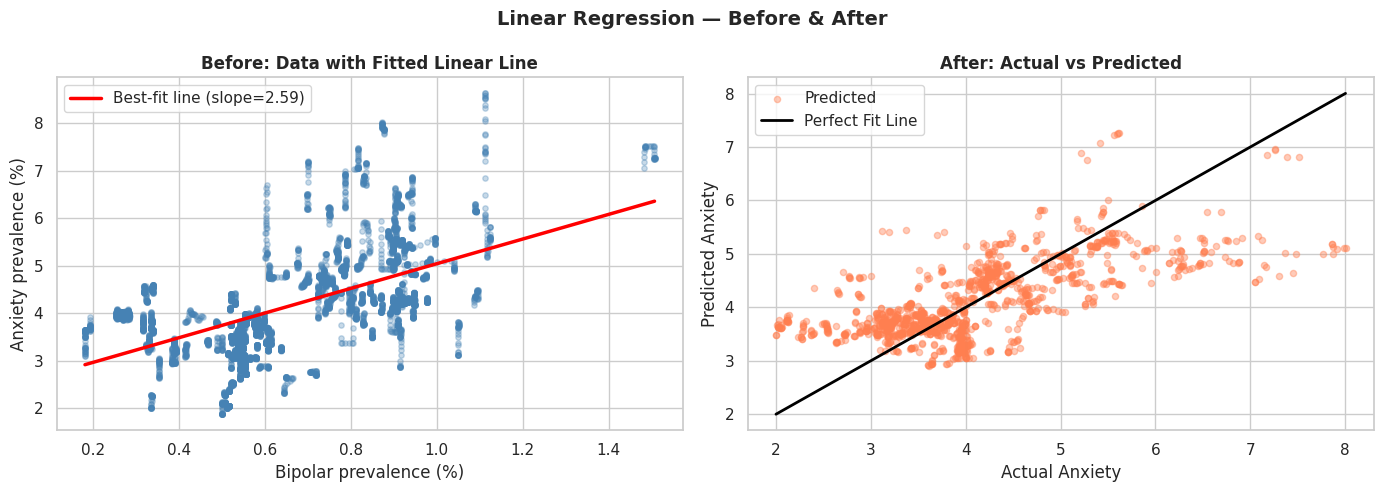

Linear Regression (OLS) — Test RMSE: 0.7733 | R2: 0.4636


In [12]:
# OLS LinearRegression = second linear implementation
lr_clean = LinearRegression()
lr_clean.fit(X_train_scaled, y_train)
y_pred_lr = lr_clean.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE: raw data (Bipolar vs Anxiety) with the fitted linear line through it
x_feat = df['Bipolar'].values.reshape(-1, 1)
y_anx  = df['Anxiety'].values
line_model = LinearRegression().fit(x_feat, y_anx)
xs = np.linspace(x_feat.min(), x_feat.max(), 100).reshape(-1, 1)

axes[0].scatter(df['Bipolar'], df['Anxiety'], alpha=0.3, color='steelblue', s=15)
axes[0].plot(xs, line_model.predict(xs), color='red', linewidth=2.5,
             label=f'Best-fit line (slope={line_model.coef_[0]:.2f})')
axes[0].set_title('Before: Data with Fitted Linear Line', fontweight='bold')
axes[0].set_xlabel('Bipolar prevalence (%)'); axes[0].set_ylabel('Anxiety prevalence (%)')
axes[0].legend()

# AFTER: actual vs predicted (full multivariate model)
axes[1].scatter(y_test, y_pred_lr, alpha=0.4, color='coral', s=20, label='Predicted')
mn, mx = min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())
axes[1].plot([mn, mx], [mn, mx], color='black', linewidth=2, label='Perfect Fit Line')
axes[1].set_title('After: Actual vs Predicted', fontweight='bold')
axes[1].set_xlabel('Actual Anxiety'); axes[1].set_ylabel('Predicted Anxiety')
axes[1].legend()

plt.suptitle('Linear Regression — Before & After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2   = r2_score(y_test, y_pred_lr)
print(f'Linear Regression (OLS) — Test RMSE: {lr_rmse:.4f} | R2: {lr_r2:.4f}')

### 4.3 — Decision Tree Regressor

In [13]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2   = r2_score(y_test, y_pred_dt)
print(f'Decision Tree — Test RMSE: {dt_rmse:.4f} | R2: {dt_r2:.4f}')

Decision Tree — Test RMSE: 0.2304 | R2: 0.9524


### 4.4 — Random Forest Regressor

In [14]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10,
                                 random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)
print(f'Random Forest — Test RMSE: {rf_rmse:.4f} | R2: {rf_r2:.4f}')

Random Forest — Test RMSE: 0.1546 | R2: 0.9786


---
## Section 5: Model Comparison & Saving Best Model

=== Model Comparison (sorted by RMSE — lower is better) ===
                                   Model     RMSE  R2_Score
                           Random Forest 0.154567  0.978568
                           Decision Tree 0.230369  0.952391
                 Linear Regression (OLS) 0.773271  0.463582
Linear Regression (SGD/Gradient Descent) 0.799641  0.426372


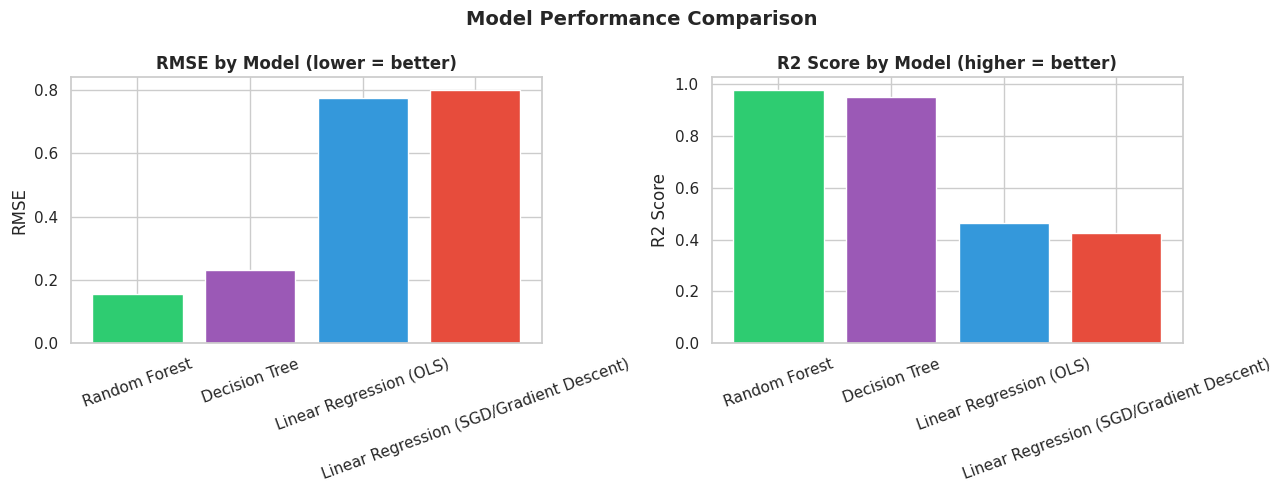

In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression (SGD/Gradient Descent)',
              'Linear Regression (OLS)', 'Decision Tree', 'Random Forest'],
    'RMSE': [sgd_rmse, lr_rmse, dt_rmse, rf_rmse],
    'R2_Score': [sgd_r2, lr_r2, dt_r2, rf_r2]
}).sort_values('RMSE').reset_index(drop=True)

print('=== Model Comparison (sorted by RMSE — lower is better) ===')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#9b59b6', '#3498db', '#e74c3c']
axes[0].bar(results['Model'], results['RMSE'], color=colors)
axes[0].set_title('RMSE by Model (lower = better)', fontweight='bold')
axes[0].set_ylabel('RMSE'); axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(results['Model'], results['R2_Score'], color=colors)
axes[1].set_title('R2 Score by Model (higher = better)', fontweight='bold')
axes[1].set_ylabel('R2 Score'); axes[1].tick_params(axis='x', rotation=20)
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Save the best model (lowest RMSE)
best_row = results.iloc[0]
best_name = best_row['Model']
model_map = {
    'Linear Regression (SGD/Gradient Descent)': sgd_model,
    'Linear Regression (OLS)': lr_clean,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}
best_model = model_map[best_name]

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

print(f'Best model: {best_name}')
print(f'  RMSE: {best_row["RMSE"]:.4f}')
print(f'  R2  : {best_row["R2_Score"]:.4f}')
print('\nSaved: best_model.pkl, scaler.pkl, entity_encoder.pkl')

Best model: Random Forest
  RMSE: 0.1546
  R2  : 0.9786

Saved: best_model.pkl, scaler.pkl, entity_encoder.pkl


---
## Section 6: Prediction on One Test Data Point (Task 2 Ready)
Demonstrates predicting on a single row of the test set — the same logic used by `predict.py` and the API.

In [17]:
loaded_model  = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

sample_index = 0
sample_input = X_test.iloc[[sample_index]]      # raw (unscaled) input
actual_value = y_test.iloc[sample_index]

sample_scaled = loaded_scaler.transform(sample_input)
predicted_value = loaded_model.predict(sample_scaled)[0]

print('=== Single Sample Prediction ===')
print(f'Input features:\n{sample_input.to_string()}\n')
print(f'Actual Anxiety prevalence   : {actual_value:.3f}')
print(f'Predicted Anxiety prevalence : {predicted_value:.3f}')
print(f'Difference                   : {abs(actual_value - predicted_value):.3f}')

=== Single Sample Prediction ===
Input features:
     Entity  Year  Schizophrenia  Depressive   Bipolar    Eating
324      10  2014       0.280634    2.947666  0.541764  0.120462

Actual Anxiety prevalence   : 3.152
Predicted Anxiety prevalence : 3.365
Difference                   : 0.213


---
## Summary

| Step | Done |
|---|---|
| Non-generic use case (mental-health anxiety prevalence) | Yes |
| Rich dataset (6,419 rows, 214 countries, 30 years) | Yes |
| Correlation heatmap | Yes |
| Histograms & scatterplots | Yes |
| Feature engineering (drop Code, encode Entity, standardize) | Yes |
| Categorical -> numeric conversion (Entity) | Yes |
| Linear Regression with gradient descent + loss curve | Yes |
| Second LR implementation (OLS) | Yes |
| Decision Tree + Random Forest | Yes |
| Scatter before & after with best-fit line | Yes |
| Best model saved as .pkl | Yes |
| Single test-point prediction | Yes |
